In [28]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_62080\27608293.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [30]:
cancer_type = "all"
cns_scores_df = pd.read_csv(cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"), sep="\t")
ogs_df = pd.read_csv(cdu.pjoin(cdu.data_path, "ogs.tsv"), sep="\t").rename(columns={"Chromosome": "chrom", "Start": "start", "End": "end", "OG_Probability_LASSO": "OG"})[["chrom", "start", "end", "OG"]]
tsgs_df = pd.read_csv(cdu.pjoin(cdu.data_path, "tsgs.tsv"), sep="\t").rename(columns={"Chromosome": "chrom", "Start": "start", "End": "end", "TSG_Probability_LASSO": "TSG"})[["chrom", "start", "end", "TSG"]]

In [31]:
merge_df = pd.merge(cns_scores_df, ogs_df, on=["chrom", "start", "end"], how="inner")
merge_df = pd.merge(merge_df, tsgs_df, on=["chrom", "start", "end"], how="inner")
merge_df.head()

,chrom,start,end,name,score,total_cn,gene,OG,TSG
0,chr1,69091,70008,ENSG00000186092,0.218983,2.512906,NaN,0.534744,0.142321
1,chr1,860260,879955,ENSG00000187634,0.218638,2.514334,NaN,0.528379,0.039523
2,chr1,879584,894689,ENSG00000188976,0.218638,2.514334,NaN,0.592945,0.015258
3,chr1,895967,901095,ENSG00000187961,0.218638,2.514334,NaN,0.554968,0.128525
4,chr1,901877,911245,ENSG00000187583,0.218638,2.514334,NaN,0.441886,0.121833


In [32]:
merge_df.sort_values(by="OG")

,chrom,start,end,name,score,total_cn,gene,OG,TSG
4478,chr12,80603233,80772870,ENSG00000165899,-0.029921,2.755924,NaN,0.077291,0.826785
2410,chr10,103544200,103578696,ENSG00000198408,0.332767,2.395813,NaN,0.077405,0.831381
2799,chr11,8127597,8190602,ENSG00000166405,0.238277,2.490536,NaN,0.077446,0.881531
13406,chr4,103422486,103538459,ENSG00000109320,0.303235,2.425857,NaN,0.080521,0.756964
2347,chr10,98592017,98740800,ENSG00000196233,0.337637,2.389305,NaN,0.082399,0.673838
...,...,...,...,...,...,...,...,...,...
5666,chr14,105235686,105262088,ENSG00000142208,0.133249,2.608626,AKT1,0.955063,0.005384
15757,chr7,55086714,55324313,ENSG00000146648,-1.114962,4.418679,EGFR,0.960102,0.006173
4060,chr12,25357723,25403870,ENSG00000133703,-0.441311,3.241837,KRAS,0.972690,0.010035
16201,chr7,140419127,140624564,ENSG00000157764,-0.325281,3.059060,BRAF,0.973806,0.038300


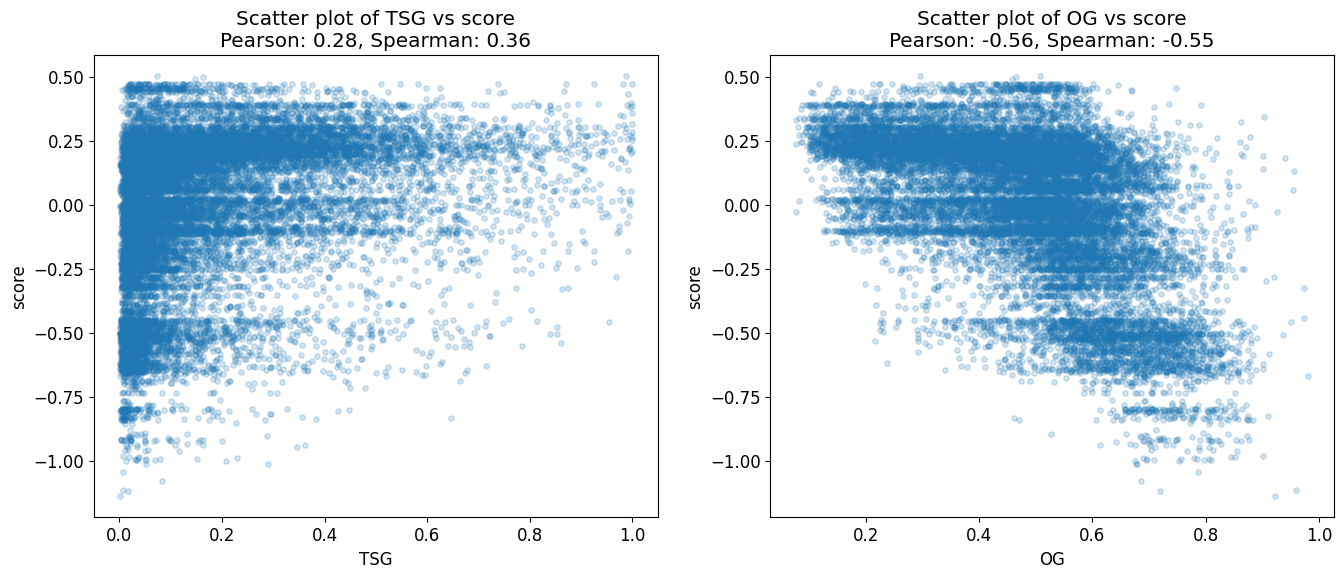

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, label in enumerate(['TSG', 'OG']):
    factor = 1
    sel_df = merge_df
    pearson = sel_df[label].corr(sel_df['score'] * factor, method='pearson')
    spearman = sel_df[label].corr(sel_df['score'] * factor, method='spearman')
    axes[i].scatter(sel_df[label], sel_df['score'] * factor, s=15, alpha=0.2, color=color_map[0])
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('score')
    axes[i].set_title(f'Scatter plot of {label} vs score\nPearson: {pearson:.2f}, Spearman: {spearman:.2f}')


In [35]:
# calculate z-score on sel_df["TSG"]
z_scores = (sel_df['TSG'] - sel_df['TSG'].mean()) / sel_df['TSG'].std()
sel_df[z_scores > 3]

,chrom,start,end,name,score,total_cn,gene,OG,TSG
73,chr1,6241329,6269449,ENSG00000116251,0.253920,2.471114,RPL22,0.187614,0.998961
88,chr1,6694228,6761984,ENSG00000007923,0.253482,2.473292,NaN,0.211586,0.893536
95,chr1,8064464,8086368,ENSG00000116285,0.253657,2.470070,NaN,0.291613,0.767555
97,chr1,8412457,8877702,ENSG00000142599,0.252147,2.474029,NaN,0.101205,0.947946
193,chr1,16450832,16482582,ENSG00000142627,0.254154,2.477978,NaN,0.185677,0.850821
...,...,...,...,...,...,...,...,...,...
17263,chr9,98637983,98776842,ENSG00000182150,0.225447,2.500758,NaN,0.101257,0.771766
17432,chr9,125606835,125667620,ENSG00000056586,0.193387,2.534901,NaN,0.142086,0.811283
17455,chr9,128024073,128129486,ENSG00000165219,0.190395,2.538791,NaN,0.120305,0.768644
17562,chr9,135937365,135947248,ENSG00000170835,0.197007,2.531204,NaN,0.188234,0.881063
